<a href="https://colab.research.google.com/github/mhasan502/Age_Estimation/blob/Jibon/Age.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notes

**Process:**
1. Prepare the Data.
2. Define the Model.
3. Train the Model.
4. Evaluate the Model.
5. Make Predictions.

**Backpropagation:**
1. Forward Pass: Compute Loss.
2. Compute local gradients.
3. Backward Pass: Compute dLoss / dWeight using Chain Rule.

**Training Pipeline:**
0. Prepare Dataset
1. Design Model: Input size, Output size, forward pass.
2. Construct Loss and Optimizer.
3. Training Loop: 
     - Forward Pass: Compute Prediction
     - Backward Pass: Gradient 
     - Update Weights.




---



# Installing Required Packages

In [ ]:
### --- For Connecting Google Colab with Local Host --- ###
# pip install jupyter_http_over_ws
## jupyter serverextension enable --py jupyter_http_over_ws
## jupyter notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8888 --NotebookApp.port_retries=0

### --- For Progress Bar --- ###
#pip install tqdm

#pip install opencv-python

# Importing Required Packages

In [ ]:
import os
import sys
import numpy as np                              # instead of python list use np if possible
from PIL import Image
from tqdm import tqdm
from parse import parse
from autocrop import Cropper
from IPython.display import clear_output

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose, Scale, Grayscale, Resize, transforms

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

#import warnings
#warnings.filterwarnings("ignore")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [ ]:
!nvidia-smi -L 

GPU 0: NVIDIA GeForce 920MX (UUID: GPU-38bea3f0-6644-d822-3fce-ca69b5e03f7d)




---



# 1. Data Preparation

## a. Import Data



In [ ]:
### --- From Google Drive --- ###

#from google.colab import drive
#drive.mount('/content/gdrive')

In [ ]:
# give appropriate location

directory = 'AgeDB/'

In [ ]:
inside = os.listdir(directory)
for i in range(10):
    print(inside[i])

0_MariaCallas_35_f.jpg
10000_GlennClose_62_f.jpg
10001_GoldieHawn_23_f.jpg
10002_GoldieHawn_24_f.jpg
10003_GoldieHawn_24_f.jpg
10004_GoldieHawn_27_f.jpg
10005_GoldieHawn_28_f.jpg
10006_GoldieHawn_29_f.jpg
10007_GoldieHawn_30_f.jpg
10008_GoldieHawn_31_f.jpg


## b. DataLoader

### * AgeDB

In [ ]:
### --- AgeDB Dataset Class --- ###

class AgeDBDataset(Dataset):

## data loading
  def __init__(self, directory, device, transform=None, preload=False, **kwargs):
    self.directory = directory
    self.transform = transform
    self.preload = preload
    self.device = device
    self.labels = []
    self.images = []
    gender_to_class_id = {
                          'm': 0,
                          'f': 1
    }

    cropper = Cropper()

    for i, file in enumerate(sorted(os.listdir(self.directory))):
      file_labels = parse('{}_{person}_{age}_{gender}.jpg', file)

      if file_labels is None:
        continue

      if self.preload:
        image = Image.open(os.path.join(self.directory, file)).convert('RGB')
        
        # Get a Numpy array of the cropped image
        cropped_array = cropper.crop(image)

        # Save the cropped image with PIL
        image = Image.fromarray(cropped_array)
        
        if self.transform is not None:
          image = self.transform(image).to(self.device)

      else:
        image = os.path.join(self.directory, file)

      self.images.append(image)
      
      gender = gender_to_class_id[file_labels['gender']]
      person = str(file_labels['person'])
      age = int(file_labels['age'])
      self.labels.append({
                          'person': person,
                          'age': age, 
                          'gender': gender
        })

## dataset[0]
  def __getitem__(self, index):
    if torch.is_tensor(index):
      index = index.tolist()

    image = self.images[index]

    if not self.preload:
      image = Image.open(image).convert('RGB')

      if self.transform is not None:
        image = self.transform(image).to(self.device)

    labels = {
             'person': self.labels[index]['person'], 
             'age': self.labels[index]['age'], 
             'gender': self.labels[index]['gender']
      }

    return image.to(self.device), labels

## len(dataset)
  def __len__(self):
    return len(self.labels)

## DataLoaders - train, validate, test
  def get_loaders(self, batch_size, train_size, test_size, random_seed, **kwargs):
    train_len = int(len(self) * train_size)
    test_len = int(len(self) * test_size)
    validate_len = len(self) - (train_len + test_len)

    self.trainDataset, self.validateDataset, self.testDataset = torch.utils.data.random_split(
      dataset = self, 
      lengths = [train_len, validate_len, test_len], 
      generator = torch.Generator().manual_seed(random_seed)
    )

    train_loader = DataLoader(self.trainDataset, batch_size=batch_size, shuffle = True)
    validate_loader = DataLoader(self.validateDataset, batch_size=batch_size, shuffle = True)
    test_loader = DataLoader(self.testDataset, batch_size=batch_size, shuffle = True)

    return train_loader, validate_loader, test_loader


## c. Using Dataset

In [ ]:
#def get_mean_and_std(loader):
#  mean = 0
#  std = 0
#  total_images_count = 0
#
#  for images, _ in loader :
#    image_count_in_a_batch = images.size(0)
#    images = images.view(image_count_in_a_batch, images.size(1), -1)
#    mean +=  images.mean(2).sum(0)
#    std += images.std(2).sum (0)
#    total_images_count += image_court_in_a_batch
#
#  mean /= total_images_count
#  std /= total_images_count
#
#  return mean, std

In [ ]:
### --- Data Transformation with Normalization --- ###

#mean, standard_deviation = get_mean_and_std(train_loader)
#
#transform = transforms.Compose([
#                                transforms.Resize((28, 28)),
#                                transforms.RandomHorizontalFlip(),
#                                transforms.RandomRotation(10),
#                                transforms.ToTensor(),
#                                transforms.Normalize(
#                                                     torch.Tensor(mean), 
#                                                     torch.Tensor(standard_deviation))
#])

In [ ]:
### --- Data Transformation --- ###

transform = transforms.Compose([transforms.Resize((64, 64)),
                                Grayscale(num_output_channels = 1),
                                transforms.RandomHorizontalFlip(),
                                transforms.RandomRotation(10),
                                transforms.ToTensor()
])

In [ ]:
### --- For AgeDB Dataset --- ###

dataset = AgeDBDataset(directory = directory,
                       device = device,
                       transform = transform                       
)

## e. EDA - Exploratory Data Analysis

In [ ]:
len(dataset)

16488

In [ ]:
dataset[0]

(tensor([[[0.0000, 0.4157, 0.4196,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.4392, 0.4431,  ..., 0.4392, 0.4314, 0.4275],
          [0.0000, 0.4627, 0.4667,  ..., 0.4392, 0.4353, 0.4275],
          ...,
          [0.7176, 0.7137, 0.7098,  ..., 0.6745, 0.6588, 0.0000],
          [0.6980, 0.6980, 0.6980,  ..., 0.6824, 0.6627, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.6706, 0.6667, 0.0000]]],
        device='cuda:0'),
 {'person': 'MariaCallas', 'age': 35, 'gender': 1})

In [ ]:
dataset[0][0][0][0][0]

tensor(0., device='cuda:0')

In [ ]:
type(dataset[0])

tuple

In [ ]:
dataset.labels[0]

{'person': 'MariaCallas', 'age': 35, 'gender': 1}

In [ ]:
dataset.images[0]

'AgeDB/0_MariaCallas_35_f.jpg'

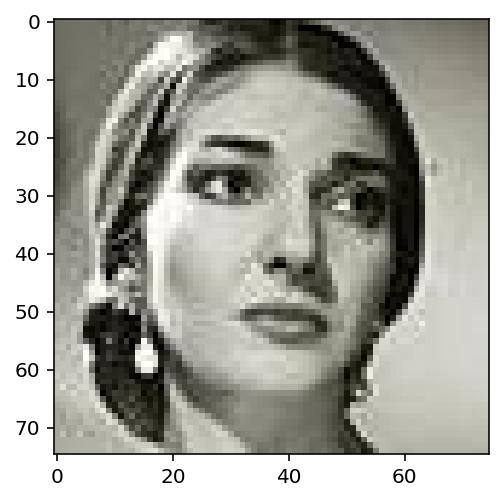

In [ ]:
plt.figure()
plt.imshow(plt.imread(dataset.images[0]))

{'person': 'GlennClose', 'age': 62, 'gender': 1}
AgeDB/10000_GlennClose_62_f.jpg


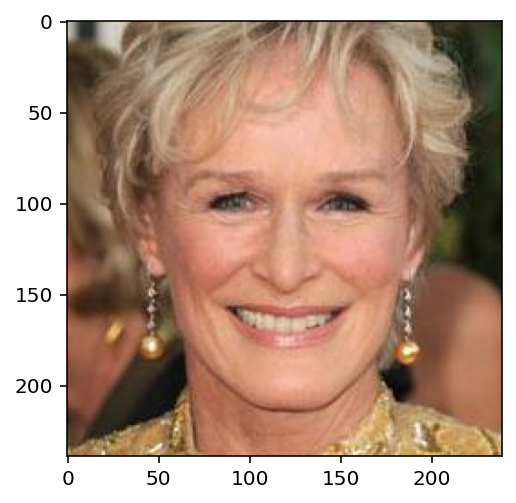

In [ ]:
print(dataset.labels[1])
print(dataset.images[1])

plt.figure()
plt.imshow(plt.imread(dataset.images[1]))

249 248
400 400


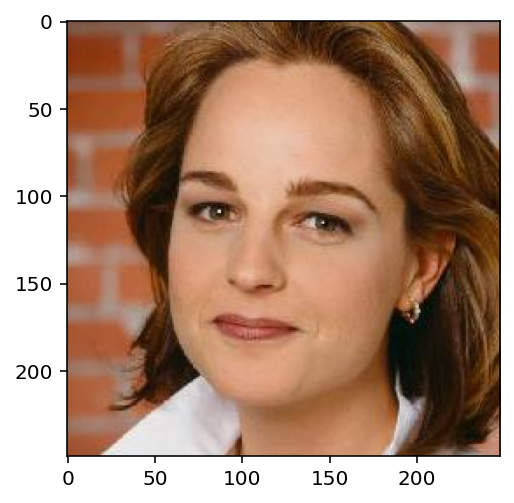

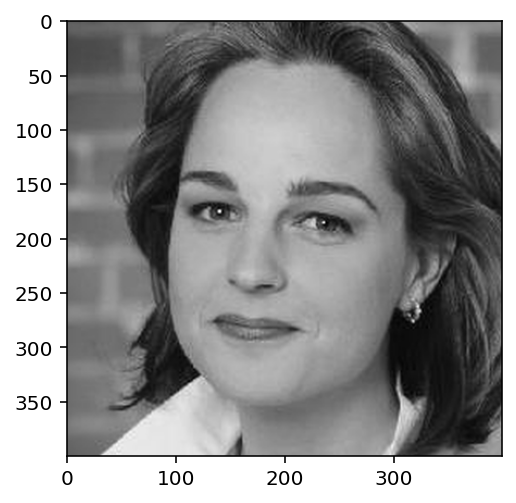

In [ ]:
plt.figure()
image = Image.open(dataset.images[48])
plt.imshow((image))
print(image.height, image.width)
image = image.resize(
    size = (400,400),
    resample=Image.LANCZOS,
)
plt.figure()
image = image.convert('LA')
plt.imshow(image)
print(image.height, image.width)

## f. Data Visualization

# 2. Model

## a. LinearNN

In [ ]:
class LinearRegression(nn.Module):
  def __init__(self, input_size, hidden_units, num_classes):
    super(LinearRegression, self).__init__()
    self.input = nn.Linear(input_size, hidden_units)
    self.LeakyReLU = nn.LeakyReLU()
    self.output = nn.Linear(hidden_units, num_classes)

  def forward(self, x):
    out = self.input(x)
    out = self.LeakyReLU(out)
    out = self.output(out)
    out = out.reshape(out.size(0), -1) #add

    return out

## b. CNN

In [ ]:
# input_channel = 1
# output_channel = 6
# kernel_size = 5
# torch.Size([64, 1, 28, 28])

#class CNN(nn.Module):
#    def __init__(self):
#        super(CNN, self).__init__()
#        self.conv1 = nn.Conv2d(1, 1, 2)
#        self.pool = nn.MaxPool2d(2, 1)
#        self.conv2 = nn.Conv2d(1, 2, 2)
#        self.pool = nn.MaxPool2d(2, 1)
#        self.conv3 = nn.Conv2d(2, 3, 2)
#        self.pool = nn.MaxPool2d(2, 1)
#        self.conv4 = nn.Conv2d(3, 4, 2)
#        self.pool = nn.MaxPool2d(2, 2)
#        self.conv5 = nn.Conv2d(4, 5, 2)
#        
#        self.fc1 = nn.Linear(5*8*8, 202)
#        self.fc2 = nn.Linear(202, 151)
#        self.fc3 = nn.Linear(151, 101)
#
#    def forward(self, x):
#        # -> n, 1, 32, 32
#        x = self.pool(F.relu(self.conv1(x)))
#        x = self.pool(F.relu(self.conv2(x)))
#        x = self.pool(F.relu(self.conv3(x)))
#        x = self.pool(F.relu(self.conv4(x)))
#        x = self.pool(F.relu(self.conv5(x)))
#        x = x.view(x.size(0), 5*8*8)
#        x = F.relu(self.fc1(x))
#        x = F.relu(self.fc2(x))
#        x = self.fc3(x)
#        
#        return x

In [ ]:
class Unit(nn.Module):
    def __init__(self,in_channels, out_channels):
        super(Unit,self).__init__()
        
        self.conv = nn.Conv2d(in_channels = in_channels,
                              kernel_size = 3,
                              out_channels = out_channels,
                              stride = 1,
                              padding = 1)
        
        self.bn = nn.BatchNorm2d(num_features = out_channels)
        self.relu = nn.LeakyReLU()

    def forward(self,input):
        output = self.conv(input)
        output = self.bn(output)
        output = self.relu(output)

        return output

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes = 101+1):
        super(CNN, self).__init__()
        
        #Create 5 layers of the unit with max pooling in between
        self.unit1 = Unit(in_channels = 1, out_channels = 3)
        self.pool1 = nn.MaxPool2d(kernel_size = 2)
        self.unit2 = Unit(in_channels = 3, out_channels = 5)
        self.unit3 = Unit(in_channels = 5, out_channels = 10)
        self.pool2 = nn.MaxPool2d(kernel_size = 2)
        self.unit4 = Unit(in_channels = 10, out_channels = 15)
        self.unit5 = Unit(in_channels = 15, out_channels = 20)
        self.avgpool = nn.AvgPool2d(kernel_size = 3)
        
        #Add all the units into the Sequential layer in exact order
        self.net = nn.Sequential(self.unit1,
                                 self.pool1, 
                                 self.unit2, 
                                 self.unit3, 
                                 self.pool2,
                                 self.unit4, 
                                 self.unit5,
                                 self.avgpool)
        
        self.fc1 = nn.Sequential(nn.Linear(in_features = 500, out_features = 250),
                                 nn.LeakyReLU(),
                                 nn.Dropout(0.2),
                                 nn.Linear(in_features = 250, out_features = num_classes))

    def forward(self, input):
        output = self.net(input)
        output = output.view(-1, 500)
        output = self.fc1(output)
        return output

## c. RNN

## d. Hyperparameters Setting

In [ ]:
### --- Hyperparameters --- ###

input_size = 64                                      # 
hidden_units = 32
num_classes = 101                                    # total possible outputs
learning_rate = 0.01
num_epochs = 10                                      # epoch = 1-forward and backward pass of ALL training samples
batch_size = 102                                      # batch_size = number of training samples in one forward & backward pass
#step_size = 10                                      # number of iterations = number of passes, each pass using [batch_size] number of samples
                                                     # e.g. 100 samples, batch_size=20 --> 100/20 = 5 iterations for 1 epoch

## e. Data Splitting 

In [ ]:
train_loader, validation_loader, test_loader = dataset.get_loaders(
    batch_size = batch_size,
    train_size = 0.7,
    test_size = 0.2,
    random_seed = 42
)

In [ ]:
len(train_loader), len(validation_loader), len(test_loader)

(114, 17, 33)

In [ ]:
sum = len(train_loader) + len(validation_loader) + len(test_loader)
sum == len(dataset)

False

In [ ]:
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

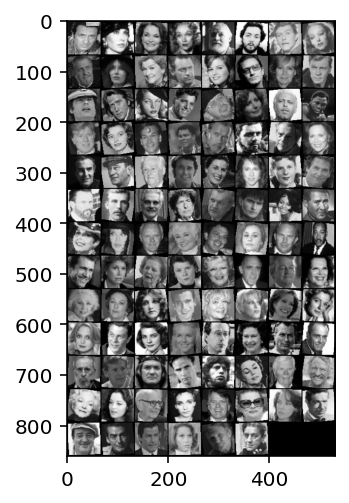

torch.Size([102, 1, 64, 64])

In [ ]:
# get some random training images
dataiter = iter(train_loader)
images, labels = dataiter.next()

# show images
imshow(torchvision.utils.make_grid(images.to('cpu')))
images.shape

## c. Using Model

In [ ]:
# model = LinearRegression(input_size = input_size,
#                          hidden_units = hidden_units,
#                          num_classes = num_classes).to(device)

In [ ]:
model = CNN().to(device)

# 3. Loss function and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

# Dont use softmax with cross entropy loss

# 4. Training Testing

## a. Training Loop

In [ ]:
def train(model, criterion, optimizer, train_loader, num_epochs):

  step_size = len(train_loader)
  for epoch in range(num_epochs):
    
    for i, (imgs, labels) in enumerate(train_loader):
      
      X_train_images = imgs.to(device)
      y_train_ages = labels['age'].to(device)
    #  print(labels['age'])
    # y_train_gender = torch.as_tensor(labels['gender']).to(device)

    # Forward Pass and Loss
      y_predicted_output_scores = model(X_train_images)
    # target = torch.randn(3).sign()
    # loss = criterion(y_predicted_output_scores, y_train_ages, target)
      loss = criterion(y_predicted_output_scores, y_train_ages)
    # loss = criterion(y_predicted_output_scores, y_train_gender)

    # Zeros Gradients
      optimizer.zero_grad()

    # Backward Pass
      loss.backward()

    # Update Weights
      optimizer.step()

    # if (epoch+1) % 10 == 0:
    # if (i+1) % step_size == 0:
     
      if i % 10 == 0:
        clear_output()
      print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, LOSS: {loss.item():.4f}')

  print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, LOSS: {loss.item():.4f}')


In [ ]:
train(model, criterion, optimizer, train_loader, num_epochs)

In [ ]:
## plot
#predicted = model(x).detach().numpy()
#plt.plot(X_numpy, y_numpy, 'ro')
#plt.plot(X_numpy, predicted, 'b')
#plt.show()

## b. Evaluate

In [ ]:
def eval(model, test_loader):
  model.eval()

  with torch.no_grad():
    correct = 0
    total = 0

    for imgs, labels in tqdm(test_loader):

      X_test_images = imgs.to(device)
      y_test_ages = labels['age'].to(device)
    # y_test_genders = torch.as_tensor(labels['gender']).to(device)
      
      y_predicted_output_scores = model(X_test_images)
    # labels = labels.to(device)

    # y_predicted_classes = y_predicted_output_scores.round()
    # accuracy = y_predicted_classes.eq.(y_test_ages).sum() / float.(y_test_ages.shape[0])
    # accuracy = y_predicted_classes.eq.(y_test_genders).sum() / float.(y_test_genders.shape[0])

      _, predicted = torch.max(y_predicted_output_scores, 1)

      total += y_test_ages.size(0)
      correct += (predicted == y_test_ages).sum().item()

    # total += y_test_genders.size(0)
    # correct += (predicted == y_test_genders).sum().item()

    # print(y_predicted_output_scores)

  print('\n')
  print(f"Accuracy: {(100 * correct) / total :.4f}%")
  print("Correct: ", correct, " Total:", total)

## c. Results

In [ ]:
### --- Training Accuracy --- ###

eval(model, train_loader)

In [ ]:
### --- Testing Accuracy --- ###

eval(model, test_loader)

In [ ]:
# model.train() # turn back training mode on after eval step



---



In [ ]:
PATH = 'F:/CSE465 PROJECT/Age_Estimation'
torch.save(model, os.path.join(PATH, 'CNNmodel.pth'))

# 5. Inferences 

In [ ]:
model = torch.load(os.path.join(PATH, 'CNNmodel.pth'))

In [ ]:
from torch.autograd import Variable
loader = transform


def image_loader(image_name):
    """load image, returns cuda tensor"""
    image = loader(image_name)
    plt.imshow(image.permute(1, 2, 0))
    image = image.float()
    image = Variable(image, requires_grad=False)
    image = image.unsqueeze(0)  #this is for VGG, may not be needed for ResNet
    return image.cuda()  #assumes that you're using GPU


In [ ]:
from PIL import Image
from autocrop import Cropper

cropper = Cropper()

# Get a Numpy array of the cropped image
cropped_array = cropper.crop('AgeDB/10000_GlennClose_62_f.jpg')

# Save the cropped image with PIL
cropped_image = Image.fromarray(cropped_array)
#cropped_image.save('cropped.png')

In [ ]:
#image = image_loader('C:/Users/nahid/OneDrive/Pictures/Screenshots/a.jpg')
#img1 = imread('C:/Users/nahid/OneDrive/Pictures/b.jpg')

plt.imshow(cropped_image)
image = image_loader(cropped_image)

output = model(image)
age = output.data.cpu().numpy().argmax()
print(age)


In [ ]:
#def predict_image(image):
#
#  image_tensor = transforms(image).float()
#  image_tensor = image_tensor.unsqueeze_(0)
#  input = Variable(image_tensor)
#  input = input.to(device)
#  output = model(input)
#  age = output.data.cpu().numpy().argmax()
#  return age 

In [ ]:
#def get_random_images(num):
#
#  inside = os.listdir(directory)
#  for i in range(10):
#    print(inside[i])
#
#  data = datasets.ImageFolder(directory, transform=transform)
#  classes = data.classes
#  indices = list(range(len(data)))
#  np.random.shuffle(indices)
#  idx = indices[:num]
#  from torch.utils.data.sampler import SubsetRandomSampler
#  sampler = SubsetRandomSampler(idx)
#  loader = torch.utils.data.DataLoader(data, 
#                 sampler=sampler, batch_size=num)
#  dataiter = iter(loader)
#  images, labels = dataiter.next()
#  return images, labels

In [ ]:
#to_pil = transforms.ToPILImage()
#images, labels = get_random_images(5)
#fig=plt.figure(figsize=(10,10))
#
#for ii in range(len(images)):
#
#  image = to_pil(images[ii])
#  index = predict_image(image)
#  sub = fig.add_subplot(1, len(images), ii+1)
#  res = int(labels[ii]) == index
#  sub.set_title(str(classes[index]) + ":" + str(res))
#  plt.axis('off')
#  plt.imshow(image)
#  
#plt.show()